# NLP Analysis — AI Coding Assistant Trust & Distrust
**COSC 3047 Assignment 2**

This notebook performs two NLP analyses on YouTube comments collected about AI coding assistants:

1. **Sentiment Analysis (VADER)** — classifies each comment as positive, negative, or neutral. VADER is a lexicon-based analyser designed for social media text. It handles informal language, capitalisation emphasis, and punctuation without requiring training data.

2. **Topic Modelling (LDA)** — discovers latent topics across the corpus and maps them to 5 research themes: productivity, reliability, security, cost, and code ownership. LDA is chosen over transformer-based approaches for interpretability and reproducibility — results are stable across runs with a fixed random seed (42), and term-topic distributions are directly inspectable.

**Input:** `data/processed/youtube/YTCommentsCleaned.csv`  
**Output:** `data/processed/nlp/`

## 1. Setup & Imports

In [31]:
import os
import json
import re
import logging
from pathlib import Path

import nltk
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from gensim import corpora
from gensim.models import LdaModel

# Silence gensim training logs
logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s", datefmt="%H:%M:%S")
log = logging.getLogger(__name__)
logging.getLogger("gensim").setLevel(logging.WARNING)

# NLTK resources
for resource in ["stopwords", "punkt", "wordnet", "omw-1.4", "punkt_tab"]:
    nltk.download(resource, quiet=True)

In [32]:
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / ".git").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

INPUT_PATH = PROJECT_ROOT / "data/processed/combined/combined_comments.csv"
OUTPUT_DIR = PROJECT_ROOT / "data/processed/nlp"
LDA_DIR    = OUTPUT_DIR / "lda_model"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(INPUT_PATH)
print(f"Loaded {len(df):,} comments")
print(f"Columns: {df.columns.tolist()}")
df.head(3)

Loaded 32,810 comments
Columns: ['platform', 'author', 'text', 'text_clean', 'published_at', 'parent_author', 'comment_type', 'source_id', 'source_title', 'like_count', 'comment_id']


,platform,author,text,text_clean,published_at,parent_author,comment_type,source_id,source_title,like_count,comment_id
0,youtube,@alsacs3635,Good overview. Thanks for sharing.,Good overview. Thanks for sharing.,2026-05-15 02:18:09+00:00,NaN,top_level,jXp5D5ZnxGM,Get to know GitHub Copilot in VS Code and be p...,0,0_yt
1,youtube,@thudtheace,Total trash!! Did you unleash copilot on GIT t...,Total trash!! Did you unleash copilot on GIT t...,2026-04-29 14:34:19+00:00,NaN,top_level,jXp5D5ZnxGM,Get to know GitHub Copilot in VS Code and be p...,0,1_yt
2,youtube,@moxopixel,Now it sucks,Now it sucks,2026-04-24 16:04:13+00:00,NaN,top_level,jXp5D5ZnxGM,Get to know GitHub Copilot in VS Code and be p...,0,2_yt


## 2. Configuration

### LDA Settings
`NUM_TOPICS = 6` matches our 5 research themes. `LDA_PASSES = 15` gives stable convergence on a corpus this size. `LDA_RANDOM_SEED = 42` ensures results are reproducible across runs.

### Theme Seeds
Each research theme is represented by seed words. After LDA training, each discovered topic is matched to the theme whose seeds overlap most with the topic's top terms. This mapping is saved to `topic_model_terms.json` and documented in the report.

### Stopwords
Domain-specific stopwords are added on top of NLTK's standard English list. These cover tool brand names (which appear in nearly every comment and carry no topical signal), YouTube creator names that polluted early topic runs, and filler phrases common in YouTube comments.

In [33]:
NUM_TOPICS      = 6
LDA_PASSES      = 15
LDA_RANDOM_SEED = 42

THEME_SEEDS = {
    "productivity":   ["faster", "speed", "time", "efficient", "workflow",
                       "automate", "quick", "save", "boilerplate", "autocomplete",
                       "suggest", "generate", "write", "complete"],
    "reliability":    ["bug", "error", "wrong", "incorrect", "broken",
                       "unreliable", "hallucinate", "mistake", "garbage",
                       "fix", "issue", "fail", "trash", "useless", "test"],
    "security":       ["security", "privacy", "data", "leak", "vulnerable",
                       "license", "safe", "risk", "expose", "telemetry"],
    "cost":           ["price", "expensive", "cheap", "cost", "subscription",
                       "free", "worth", "money", "pay", "pricing", "plan", "open"],
    "code_ownership": ["copyright", "ownership", "training", "stolen",
                       "plagiarism", "license", "legal", "intellectual",
                       "property", "scraping"],
    "job_displacement": ["job", "replace", "replacing", "replaced", "unemployed",
                     "fired", "layoff", "obsolete", "human", "engineer",
                     "developer", "programmer", "junior", "hire", "career"],
}

EXTRA_STOPWORDS = {
    "ai", "code", "coding", "use", "using", "used", "tool", "like", "just",
    "get", "got", "one", "would", "could", "really", "think", "know", "also",
    "github", "copilot", "cursor", "claude", "video", "comment", "people",
    "thing", "things", "make", "good", "great", "way", "work", "working",
    "much", "many", "still", "even", "well", "want", "need", "new", "go",
    # Creator/video noise
    "ali", "antigravity", "composer", "lex", "fridman", "bernie", "sanders",
    "cowork", "tutorial", "microsoft", "vscode", "codex", "gemini", "gpt",
    # Filler
    "thank", "thanks", "please", "nice", "awesome", "amazing", "love",
    "best", "better", "see", "say", "going", "something", "actually",
    "lol", "guy", "lot", "take", "first", "right", "already", "seems",
    "though", "basically", "completely"
}

stop_words = set(stopwords.words("english")) | EXTRA_STOPWORDS
print(f"Total stopwords: {len(stop_words)}")

Total stopwords: 278


## 3. Text Preprocessing

Comments are preprocessed before LDA by:
1. Lowercasing
2. Removing URLs, @mentions, #hashtags
3. Removing non-alphabetic characters
4. Tokenising
5. Removing stopwords and tokens shorter than 3 characters
6. Lemmatising

Note: VADER sentiment runs on **raw** text before preprocessing — preserving capitalisation and punctuation which VADER uses as sentiment signals.

In [34]:
def preprocess_text(text: str, stop_words: set, lemmatizer: WordNetLemmatizer) -> list:
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[@#]\w+", "", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    tokens = word_tokenize(text)
    tokens = [
        lemmatizer.lemmatize(t)
        for t in tokens
        if t not in stop_words and len(t) >= 3
    ]
    return tokens

print("preprocess_text defined.")

preprocess_text defined.


## 4. Sentiment Analysis (VADER)

VADER (Valence Aware Dictionary and sEntiment Reasoner) assigns each comment a compound score from −1 (most negative) to +1 (most positive). Following VADER's recommended thresholds:
- **Positive**: compound ≥ 0.05
- **Negative**: compound ≤ −0.05
- **Neutral**: between −0.05 and 0.05

VADER is particularly suited to YouTube comments because it accounts for capitalisation (`GREAT` vs `great`), punctuation emphasis (`great!!!`), and common internet slang.

In [35]:
def run_sentiment_analysis(df: pd.DataFrame) -> pd.DataFrame:
    analyser = SentimentIntensityAnalyzer()
    results = []
    
    # Handle both YouTube-only (commentTextClean) and combined (text_clean) column names
    text_col = "text_clean" if "text_clean" in df.columns else "commentTextClean"
    
    for text in df[text_col].fillna(""):
        scores = analyser.polarity_scores(str(text))
        compound = scores["compound"]
        label = "neutral"
        if compound >= 0.05:
            label = "positive"
        elif compound <= -0.05:
            label = "negative"
        results.append({
            "sentiment_compound": compound,
            "sentiment_pos":      scores["pos"],
            "sentiment_neg":      scores["neg"],
            "sentiment_neu":      scores["neu"],
            "sentiment_label":    label
        })
    return pd.concat([df.reset_index(drop=True), pd.DataFrame(results)], axis=1)

In [36]:
sent_df = run_sentiment_analysis(df)

print(f"Sentiment distribution:")
print(sent_df["sentiment_label"].value_counts())
print(f"\nAverage compound score: {sent_df['sentiment_compound'].mean():.4f}")
sent_df[["text_clean", "sentiment_compound", "sentiment_label"]].head(5)

Sentiment distribution:
sentiment_label
positive    18188
neutral      7642
negative     6980
Name: count, dtype: int64

Average compound score: 0.2235


,text_clean,sentiment_compound,sentiment_label
0,Good overview. Thanks for sharing.,0.8225,positive
1,Total trash!! Did you unleash copilot on GIT t...,0.4276,positive
2,Now it sucks,-0.3612,negative
3,CNTL + ENTER sends stuff to the terminal for m...,0.0000,neutral
4,Wonderful Explanation,0.5719,positive


### Sentiment Visualisations

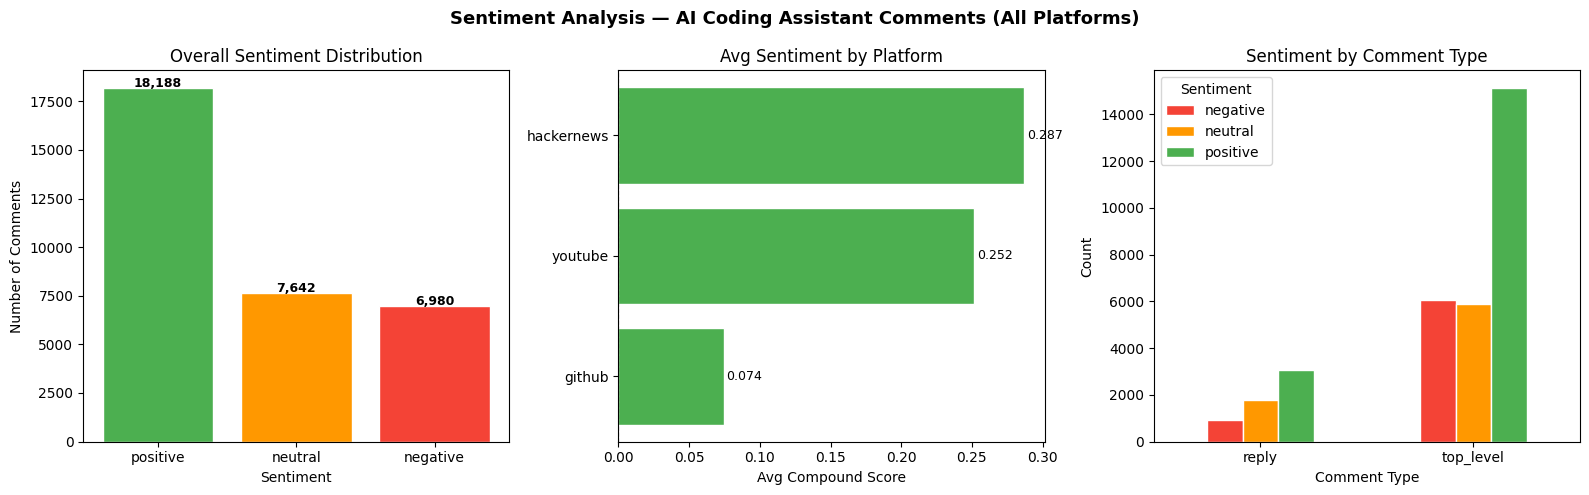

Saved sentiment_overview.png


In [37]:
COLORS = {"positive": "#4CAF50", "neutral": "#FF9800", "negative": "#F44336"}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Sentiment Analysis — AI Coding Assistant Comments (All Platforms)", fontsize=13, fontweight="bold")

# Plot 1 — Overall distribution
counts = sent_df["sentiment_label"].value_counts()
axes[0].bar(counts.index, counts.values, color=[COLORS[s] for s in counts.index], edgecolor="white")
axes[0].set_title("Overall Sentiment Distribution")
axes[0].set_xlabel("Sentiment")
axes[0].set_ylabel("Number of Comments")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, f"{v:,}", ha="center", fontweight="bold", fontsize=9)

# Plot 2 — Avg sentiment by platform
avg_sent = sent_df.groupby("platform")["sentiment_compound"].mean().sort_values()
bar_colors = ["#F44336" if v < 0 else "#4CAF50" for v in avg_sent.values]
axes[1].barh(avg_sent.index, avg_sent.values, color=bar_colors, edgecolor="white")
axes[1].axvline(x=0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_title("Avg Sentiment by Platform")
axes[1].set_xlabel("Avg Compound Score")
for i, v in enumerate(avg_sent.values):
    axes[1].text(v + 0.002, i, f"{v:.3f}", va="center", fontsize=9)

# Plot 3 — Sentiment by comment type
type_col = "comment_type" if "comment_type" in sent_df.columns else "commentType"
type_sent = sent_df.groupby([type_col, "sentiment_label"]).size().unstack(fill_value=0)
type_sent.plot(kind="bar", ax=axes[2], color=[COLORS.get(c, "#9E9E9E") for c in type_sent.columns], edgecolor="white")
axes[2].set_title("Sentiment by Comment Type")
axes[2].set_xlabel("Comment Type")
axes[2].set_ylabel("Count")
axes[2].tick_params(axis="x", rotation=0)
axes[2].legend(title="Sentiment")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "sentiment_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved sentiment_overview.png")

## 5. Topic Modelling (LDA)

LDA models each comment as a mixture of latent topics, and each topic as a probability distribution over words. With `NUM_TOPICS=6` we expect to recover topics corresponding to our 5 research themes.

**Key decisions:**
- `no_below=5` — terms in fewer than 5 documents discarded as noise
- `no_above=0.7` — terms in more than 70% of documents discarded as uninformative
- `passes=15` — multiple passes improve topic stability
- `random_state=42` — fixed seed ensures reproducibility
- Saved model is loaded if available — delete `data/processed/nlp/lda_model/` to force retrain

In [38]:
def run_topic_modelling(sent_df: pd.DataFrame, stop_words: set):
    lemmatizer = WordNetLemmatizer()
    log.info("Preprocessing text for LDA...")
    
    # Handle both column name conventions
    text_col = "text_clean" if "text_clean" in sent_df.columns else "commentTextClean"
    
    texts = [
        preprocess_text(str(text), stop_words, lemmatizer)
        for text in sent_df[text_col].fillna("")
    ]
    texts = [t for t in texts if len(t) > 0]
    log.info(f"  {len(texts):,} non-empty documents after preprocessing")

    dictionary = corpora.Dictionary(texts)
    dictionary.filter_extremes(no_below=5, no_above=0.7)
    log.info(f"  Vocabulary size after filtering: {len(dictionary):,} terms")

    corpus = [dictionary.doc2bow(text) for text in texts]

    log.info(f"Training LDA ({NUM_TOPICS} topics, {LDA_PASSES} passes)...")
    lda_model = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=NUM_TOPICS,
        passes=LDA_PASSES,
        random_state=LDA_RANDOM_SEED,
        alpha="auto",
        eta="auto"
    )
    log.info("LDA training complete.")

    LDA_DIR.mkdir(parents=True, exist_ok=True)
    lda_model.save(str(LDA_DIR / "lda.model"))
    dictionary.save(str(LDA_DIR / "dictionary.gensim"))
    log.info(f"Model saved to {LDA_DIR}")

    return lda_model, dictionary

def map_topics_to_themes(lda_model: LdaModel, num_words: int = 15):
    topic_map = {}
    topic_terms = {}
    for topic_id in range(NUM_TOPICS):
        terms = [word for word, _ in lda_model.show_topic(topic_id, topn=num_words)]
        topic_terms[topic_id] = terms
        scores = {theme: sum(1 for t in terms if t in seeds) for theme, seeds in THEME_SEEDS.items()}
        best_theme = max(scores, key=scores.get)
        topic_map[topic_id] = best_theme if scores[best_theme] > 0 else "other"
        log.info(f"  Topic {topic_id} → '{topic_map[topic_id]}' | top terms: {', '.join(terms[:8])}")
    return topic_map, topic_terms


def assign_topics_to_comments(sent_df: pd.DataFrame, lda_model: LdaModel,
                               dictionary: corpora.Dictionary, topic_map: dict, stop_words: set) -> pd.DataFrame:
    lemmatizer = WordNetLemmatizer()
    topic_ids, topic_labels, topic_scores = [], [], []
    
    # Handle both column name conventions
    text_col = "text_clean" if "text_clean" in sent_df.columns else "commentTextClean"
    
    log.info("Assigning topics to comments...")
    for text in sent_df[text_col].fillna(""):
        tokens = preprocess_text(str(text), stop_words, lemmatizer)
        bow = dictionary.doc2bow(tokens)
        if not bow:
            topic_ids.append(None)
            topic_labels.append("unknown")
            topic_scores.append(0.0)
            continue
        topic_dist = lda_model.get_document_topics(bow)
        if not topic_dist:
            topic_ids.append(None)
            topic_labels.append("unknown")
            topic_scores.append(0.0)
            continue
        dominant = max(topic_dist, key=lambda x: x[1])
        topic_ids.append(int(dominant[0]))
        topic_labels.append(topic_map.get(dominant[0], "other"))
        topic_scores.append(round(float(dominant[1]), 4))
    
    log.info("Topic assignment complete.")
    result = sent_df.copy()
    result["dominant_topic_id"] = topic_ids
    result["topic_label"]       = topic_labels
    result["topic_score"]       = topic_scores
    return result

### Train or Load LDA Model

In [39]:
if (LDA_DIR / "lda.model").exists() and (LDA_DIR / "dictionary.gensim").exists():
    log.info("Found existing LDA model — loading instead of retraining.")
    log.info("Delete data/processed/nlp/lda_model/ to force retrain.")
    lda_model = LdaModel.load(str(LDA_DIR / "lda.model"))
    dictionary = corpora.Dictionary.load(str(LDA_DIR / "dictionary.gensim"))
else:
    log.info("No saved model found — training from scratch.")
    lda_model, dictionary = run_topic_modelling(sent_df, stop_words)

# Map topics to themes
log.info("Mapping topics to research themes...")
topic_map, topic_terms = map_topics_to_themes(lda_model)

# Save topic terms for report
topic_terms_output = {
    str(tid): {"theme": topic_map[tid], "top_terms": terms}
    for tid, terms in topic_terms.items()
}
with open(OUTPUT_DIR / "topic_model_terms.json", "w") as f:
    json.dump(topic_terms_output, f, indent=2)
print("Saved topic_model_terms.json")

21:02:32 [INFO] No saved model found — training from scratch.
21:02:32 [INFO] Preprocessing text for LDA...
21:02:36 [INFO]   31,639 non-empty documents after preprocessing
21:02:37 [INFO]   Vocabulary size after filtering: 7,950 terms
21:02:37 [INFO] Training LDA (6 topics, 15 passes)...
21:03:04 [INFO] LDA training complete.
21:03:04 [INFO] Model saved to /Users/gayathwethmin/Downloads/social_media_2/data/processed/nlp/lda_model
21:03:04 [INFO] Mapping topics to research themes...
21:03:04 [INFO]   Topic 0 → 'job_displacement' | top terms: vibe, test, review, team, human, done, replace, post
21:03:04 [INFO]   Topic 1 → 'reliability' | top terms: version, app, file, window, desktop, enabled, issue, bug
21:03:04 [INFO]   Topic 2 → 'productivity' | top terms: time, problem, day, software, llm, write, developer, back
21:03:04 [INFO]   Topic 3 → 'reliability' | top terms: user, model, context, mcp, issue, prompt, log, token
21:03:04 [INFO]   Topic 4 → 'other' | top terms: additional, tool

Saved topic_model_terms.json


### Assign Topics to Comments

In [40]:
topic_df = assign_topics_to_comments(sent_df, lda_model, dictionary, topic_map, stop_words)

print("Topic distribution:")
print(topic_df["topic_label"].value_counts())

# Save enriched comments
topic_df.to_csv(OUTPUT_DIR / "comments_with_topics.csv", index=False)
print(f"\nSaved comments_with_topics.csv ({len(topic_df):,} rows)")

21:03:04 [INFO] Assigning topics to comments...


21:03:09 [INFO] Topic assignment complete.


Topic distribution:
topic_label
productivity        13741
reliability         10988
other                3817
cost                 2104
unknown              1532
job_displacement      628
Name: count, dtype: int64

Saved comments_with_topics.csv (32,810 rows)


### Topic Visualisations

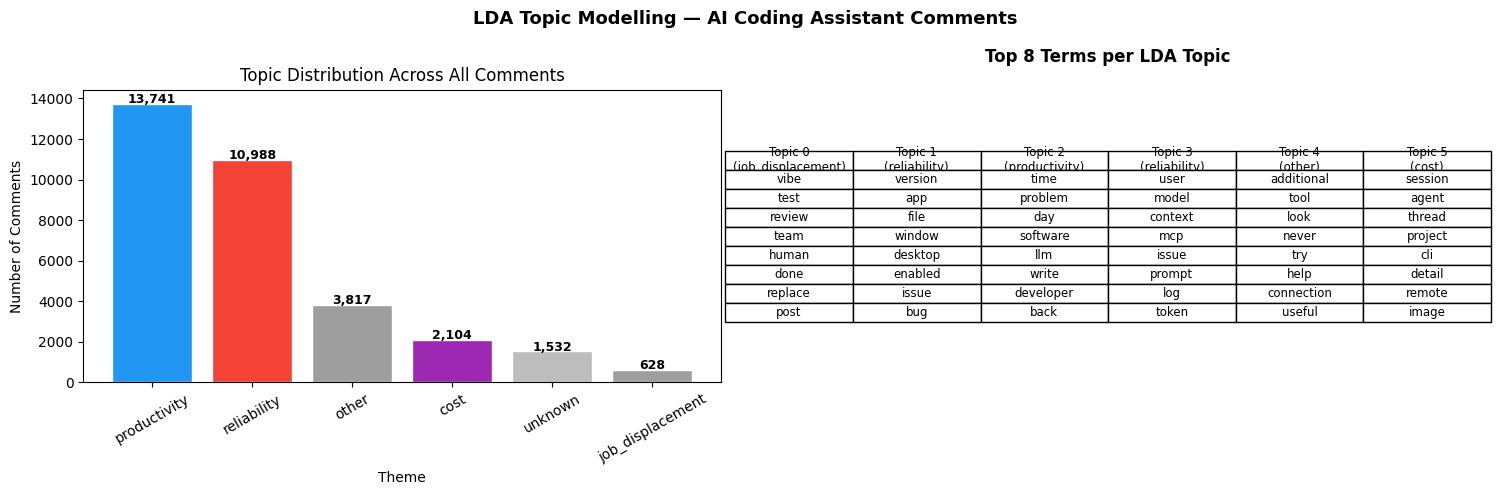

Saved topic_overview.png


In [41]:
TOPIC_COLORS = {
    "productivity": "#2196F3", "reliability": "#F44336",
    "security": "#FF9800", "cost": "#9C27B0",
    "code_ownership": "#009688", "other": "#9E9E9E", "unknown": "#BDBDBD"
}

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("LDA Topic Modelling — AI Coding Assistant Comments", fontsize=13, fontweight="bold")

# Plot 1 — Topic distribution
topic_counts = topic_df["topic_label"].value_counts()
bar_colors = [TOPIC_COLORS.get(t, "#9E9E9E") for t in topic_counts.index]
axes[0].bar(topic_counts.index, topic_counts.values, color=bar_colors, edgecolor="white")
axes[0].set_title("Topic Distribution Across All Comments")
axes[0].set_xlabel("Theme")
axes[0].set_ylabel("Number of Comments")
axes[0].tick_params(axis="x", rotation=30)
for i, v in enumerate(topic_counts.values):
    axes[0].text(i, v + 30, f"{v:,}", ha="center", fontsize=9, fontweight="bold")

# Plot 2 — Top 8 terms per topic as a table
terms_data = {f"Topic {tid}\n({topic_map[tid]})": topic_terms[tid][:8] for tid in range(NUM_TOPICS)}
terms_df = pd.DataFrame(terms_data)
axes[1].axis("off")
table = axes[1].table(cellText=terms_df.values, colLabels=terms_df.columns,
                      cellLoc="center", loc="center")
table.auto_set_font_size(False)
table.set_fontsize(8.5)
table.scale(1.2, 1.5)
axes[1].set_title("Top 8 Terms per LDA Topic", fontweight="bold", pad=20)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "topic_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved topic_overview.png")

## 6. Cross-Analysis — Sentiment × Topic

This is the key analytical step for the research question. By combining sentiment scores with topic labels we can identify:
- Which concern themes drive the most negative sentiment (distrust signals)
- Which themes are associated with positive sentiment (trust signals)
- How sentiment varies across topics — informing the network analysis stage

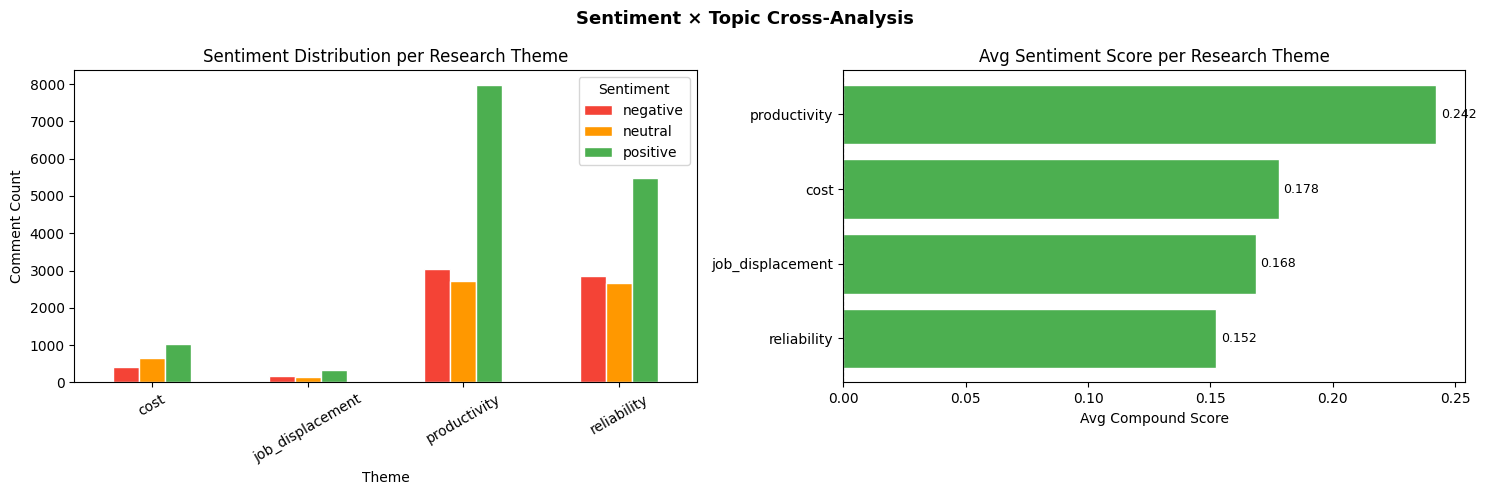

Saved sentiment_by_topic.png


In [42]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Sentiment × Topic Cross-Analysis", fontsize=13, fontweight="bold")

# Plot 1 — Sentiment breakdown per topic (stacked bar)
topic_sent = topic_df[topic_df["topic_label"].isin(THEME_SEEDS.keys())].groupby(
    ["topic_label", "sentiment_label"]
).size().unstack(fill_value=0)
topic_sent.plot(kind="bar", ax=axes[0],
                color=[COLORS.get(c, "#9E9E9E") for c in topic_sent.columns],
                edgecolor="white")
axes[0].set_title("Sentiment Distribution per Research Theme")
axes[0].set_xlabel("Theme")
axes[0].set_ylabel("Comment Count")
axes[0].tick_params(axis="x", rotation=30)
axes[0].legend(title="Sentiment")

# Plot 2 — Average compound sentiment per topic
avg_by_topic = topic_df[topic_df["topic_label"].isin(THEME_SEEDS.keys())].groupby(
    "topic_label"
)["sentiment_compound"].mean().sort_values()
bar_colors = ["#F44336" if v < 0 else "#4CAF50" for v in avg_by_topic.values]
axes[1].barh(avg_by_topic.index, avg_by_topic.values, color=bar_colors, edgecolor="white")
axes[1].axvline(x=0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_title("Avg Sentiment Score per Research Theme")
axes[1].set_xlabel("Avg Compound Score")
for i, v in enumerate(avg_by_topic.values):
    axes[1].text(v + 0.002, i, f"{v:.3f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "sentiment_by_topic.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved sentiment_by_topic.png")

### Positive vs Negative Word Clouds

Words most associated with trust (positive comments) and distrust (negative comments) across all collected comments.

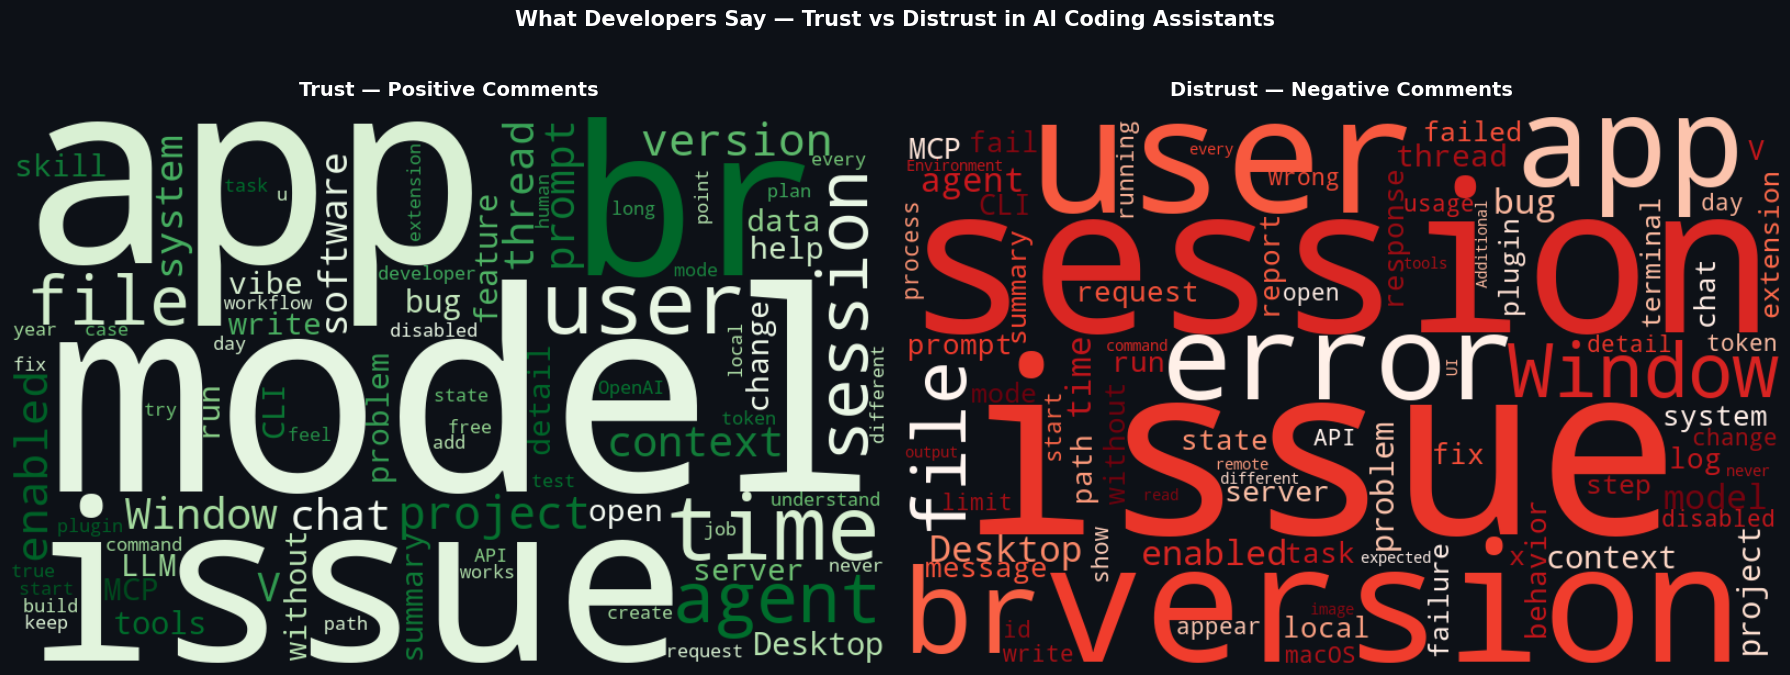

Saved wordcloud_trust_distrust.png


In [43]:
from wordcloud import WordCloud

# Filter positive and negative comments
text_col = "text_clean" if "text_clean" in sent_df.columns else "commentTextClean"

positive_text = " ".join(
    sent_df[sent_df["sentiment_label"] == "positive"][text_col].fillna("")
)
negative_text = " ".join(
    sent_df[sent_df["sentiment_label"] == "negative"][text_col].fillna("")
)
# Build stopwords — combine NLTK + our domain stopwords
from nltk.corpus import stopwords as nltk_sw
wc_stopwords = set(nltk_sw.words("english")) | EXTRA_STOPWORDS | {
    "one", "will", "get", "got", "use", "used", "using", "can", "just",
    "like", "know", "think", "really", "good", "great", "make", "want",
    "going", "actually", "something", "even", "still", "well", "much",
    "also", "back", "give", "take", "see", "say", "said", "need", "look"
}

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor("#0d1117")

# Positive word cloud
wc_pos = WordCloud(
    width=800, height=500,
    background_color="#0d1117",
    colormap="Greens",
    stopwords=wc_stopwords,
    max_words=80,
    prefer_horizontal=0.85,
    collocations=False
).generate(positive_text)

axes[0].imshow(wc_pos, interpolation="bilinear")
axes[0].axis("off")
axes[0].set_title("Trust — Positive Comments", fontsize=14, fontweight="bold",
                  color="white", pad=15)
axes[0].set_facecolor("#0d1117")

# Negative word cloud
wc_neg = WordCloud(
    width=800, height=500,
    background_color="#0d1117",
    colormap="Reds",
    stopwords=wc_stopwords,
    max_words=80,
    prefer_horizontal=0.85,
    collocations=False
).generate(negative_text)

axes[1].imshow(wc_neg, interpolation="bilinear")
axes[1].axis("off")
axes[1].set_title("Distrust — Negative Comments", fontsize=14, fontweight="bold",
                  color="white", pad=15)
axes[1].set_facecolor("#0d1117")

plt.suptitle("What Developers Say — Trust vs Distrust in AI Coding Assistants",
             fontsize=15, fontweight="bold", color="white", y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "wordcloud_trust_distrust.png", dpi=150,
            bbox_inches="tight", facecolor="#0d1117")
plt.show()
print("Saved wordcloud_trust_distrust.png")

### Topic Distribution by Channel (Heatmap)

Which channels drive which concern themes. Each cell shows the percentage of that channel's comments assigned to each topic — revealing how different communities shape the discourse around AI coding assistants.

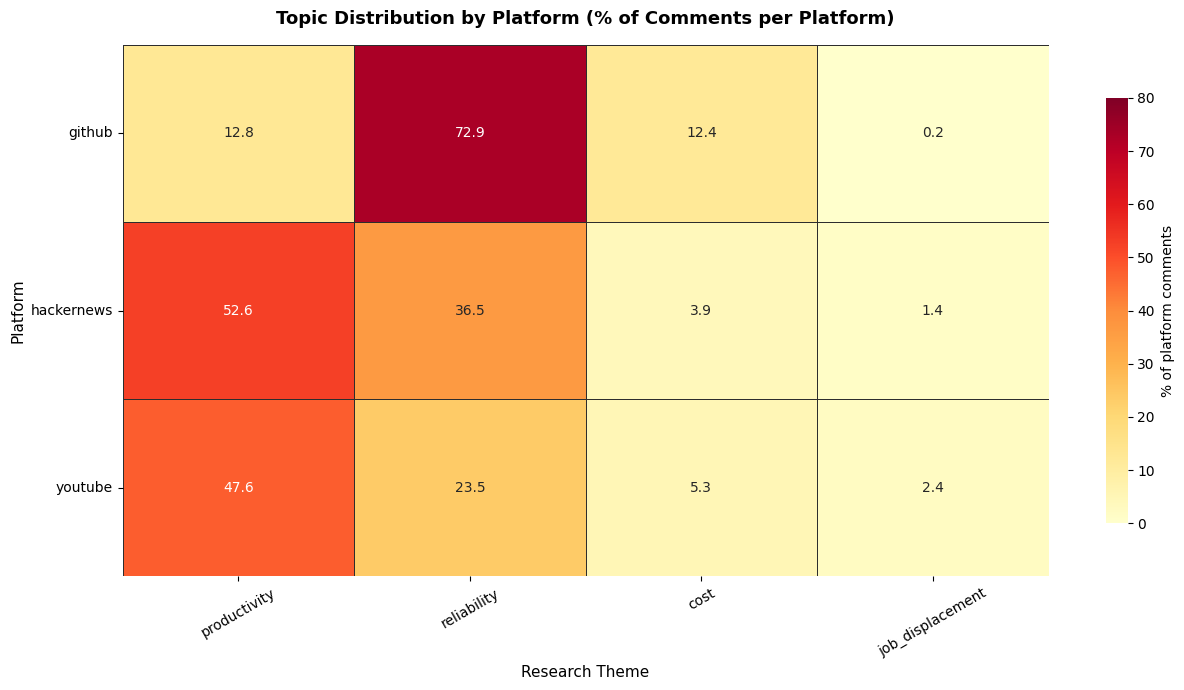

Saved topic_channel_heatmap.png


In [44]:
# Use platform instead of channelTitle for combined dataset
group_col = "platform" if "platform" in topic_df.columns else "channelTitle"

top_groups = topic_df[group_col].value_counts().head(10).index
heatmap_df = topic_df[topic_df[group_col].isin(top_groups)]

# Build pivot — percentage of each topic per platform/channel
pivot = (
    heatmap_df.groupby([group_col, "topic_label"])
    .size()
    .unstack(fill_value=0)
)

# Convert to row percentages
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

# Keep only the 5 research themes + job_displacement, drop other/unknown
theme_cols = [c for c in ["productivity", "reliability", "security",
                           "cost", "code_ownership", "job_displacement"]
              if c in pivot_pct.columns]
pivot_pct = pivot_pct[theme_cols]

# Shorten names for readability
pivot_pct.index = [name[:30] for name in pivot_pct.index]

fig, ax = plt.subplots(figsize=(13, 7))

sns.heatmap(
    pivot_pct,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5,
    linecolor="#2d2d2d",
    cbar_kws={"label": "% of platform comments", "shrink": 0.8},
    ax=ax,
    vmin=0,
    vmax=80
)

ax.set_title("Topic Distribution by Platform (% of Comments per Platform)",
             fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("Research Theme", fontsize=11)
ax.set_ylabel("Platform", fontsize=11)
ax.tick_params(axis="x", rotation=30)
ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "topic_channel_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved topic_channel_heatmap.png")

## 7. Summary Statistics

In [45]:
# Handle both column name conventions
group_col   = "platform"     if "platform"     in topic_df.columns else "channelTitle"
type_col    = "comment_type" if "comment_type"  in topic_df.columns else "commentType"

summary = {
    "total_comments":        len(topic_df),
    "overall_sentiment":     topic_df["sentiment_label"].value_counts().to_dict(),
    "overall_topics":        topic_df["topic_label"].value_counts().to_dict(),
    "avg_sentiment_by_platform": (
        topic_df.groupby(group_col)["sentiment_compound"].mean().round(4).to_dict()
    ),
    "sentiment_by_topic": (
        topic_df.groupby(["topic_label", "sentiment_label"])
        .size().unstack(fill_value=0).to_dict()
    ),
    "avg_sentiment_by_topic": (
        topic_df.groupby("topic_label")["sentiment_compound"].mean().round(4).to_dict()
    ),
    "sentiment_by_comment_type": (
        topic_df.groupby([type_col, "sentiment_label"])
        .size().unstack(fill_value=0).to_dict()
    )
}

with open(OUTPUT_DIR / "summary_stats.json", "w") as f:
    json.dump(summary, f, indent=2)

print("=" * 50)
print("NLP Pipeline Complete")
print(f"  Total comments analysed: {summary['total_comments']:,}")
print(f"  Sentiment:  {summary['overall_sentiment']}")
print(f"  Topics:     {summary['overall_topics']}")
print(f"  Avg sentiment by platform:")
for platform, score in summary["avg_sentiment_by_platform"].items():
    label = "positive" if score > 0.05 else "negative" if score < -0.05 else "neutral"
    print(f"    {platform:15s}: {score:+.4f} ({label})")
print(f"  Avg sentiment by topic:")
for topic, score in summary["avg_sentiment_by_topic"].items():
    label = "positive" if score > 0.05 else "negative" if score < -0.05 else "neutral"
    print(f"    {topic:15s}: {score:+.4f} ({label})")
print("=" * 50)

NLP Pipeline Complete
  Total comments analysed: 32,810
  Sentiment:  {'positive': 18188, 'neutral': 7642, 'negative': 6980}
  Topics:     {'productivity': 13741, 'reliability': 10988, 'other': 3817, 'cost': 2104, 'unknown': 1532, 'job_displacement': 628}
  Avg sentiment by platform:
    github         : +0.0743 (positive)
    hackernews     : +0.2871 (positive)
    youtube        : +0.2516 (positive)
  Avg sentiment by topic:
    cost           : +0.1778 (positive)
    job_displacement: +0.1685 (positive)
    other          : +0.3796 (positive)
    productivity   : +0.2421 (positive)
    reliability    : +0.1524 (positive)
    unknown        : +0.2632 (positive)


## 8. Outputs

All outputs saved to `data/processed/nlp/`:

| File | Description |
|---|---|
| `comments_with_topics.csv` | Every comment with VADER scores + topic label — input for network analysis |
| `topic_model_terms.json` | Top terms per LDA topic — used to justify theme mapping in report |
| `summary_stats.json` | Aggregate breakdowns by topic, sentiment, channel, comment type |
| `sentiment_overview.png` | Sentiment distribution charts |
| `topic_overview.png` | Topic distribution + top terms table |
| `sentiment_by_topic.png` | Cross-analysis of sentiment per research theme |
| `lda_model/` | Saved LDA model — load instead of retraining on subsequent runs |